# Superstore Sales Analysis

This project will look at 4 years of order data from the Sample Superstore dataset to see where the business is actually making money vs just generating sales. Revenue growing doesn't mean profit is growing, some orders are properly profitable and others lose money outright, sometimes on the exact same product just sold at a different discount.

This notebook has the SQL analysis (using SQLite) and then a small classification model at the end to see if order profitability can actually be predicted before the order happens.

## Dataset

9,994 order line items, 21 columns covering order details, customer segment, geography, product hierarchy and the financial numbers. Covers Jan 2014 to Dec 2017.

## Loading into SQLite

Reading the raw excel file in and writing it into a SQLite db so I can actually run SQL against it properly instead of doing everything in pandas.

In [25]:
import pandas as pd
import sqlite3

df = pd.read_excel('superstore.xls')

conn = sqlite3.connect('superstore.db')
df.to_sql('orders_raw', conn, if_exists='replace', index=False)
conn.close()

print('This is complete and the excel file has been successfully loaded into the SQLite database.')

This is complete and the excel file has been successfully loaded into the SQLite database.


## Setup

Connecting to the db and pulling the table into a dataframe for a first look.

In [26]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('superstore.db')
df = pd.read_sql('SELECT * FROM orders_raw', conn)

print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Checking for missing values and duplicates

Before doing anything else wanted to make sure the data was actually clean, checking nulls, duplicate rows and duplicate row ids since that should be a unique key.

In [27]:
print('nulls per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('duplicate rows:', df.duplicated().sum())
print('duplicate row ids:', df['Row ID'].duplicated().sum())

nulls per column:
Series([], dtype: int64)
duplicate rows: 0
duplicate row ids: 0


## Checking categories and dates

Making sure the category columns don't have weird spelling inconsistencies, and that ship date is never before order date.

In [28]:
print('categories:', df['Category'].unique())
print('sub-categories:', df['Sub-Category'].nunique())
print('segments:', df['Segment'].unique())
print('regions:', df['Region'].unique())
print('ship modes:', df['Ship Mode'].unique())

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print('rows where ship date is before order date:', (df['Ship Date'] < df['Order Date']).sum())

categories: ['Furniture' 'Office Supplies' 'Technology']
sub-categories: 17
segments: ['Consumer' 'Corporate' 'Home Office']
regions: ['South' 'West' 'Central' 'East']
ship modes: ['Second Class' 'Standard Class' 'First Class' 'Same Day']
rows where ship date is before order date: 0


## Checking numeric ranges

Quick check for anything obviously wrong, negative sales, discounts over 100%, that kind of thing.

In [29]:
print('sales min/max:', df['Sales'].min(), df['Sales'].max())
print('quantity min/max:', df['Quantity'].min(), df['Quantity'].max())
print('discount min/max:', df['Discount'].min(), df['Discount'].max())
print('profit min/max:', df['Profit'].min(), df['Profit'].max())

sales min/max: 0.44399999999999995 22638.48
quantity min/max: 1 14
discount min/max: 0.0 0.8
profit min/max: -6599.978000000001 8399.975999999999


## Saving the cleaned table

Turned out the dataset was already pretty clean, no nulls, no duplicates, dates all made sense, so there wasn't actually much cleaning to do. Renamed the columns to snake_case so they're easier to use in SQL and saved this as its own table.

In [30]:
df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_') for c in df.columns]

df.to_sql('orders_clean', conn, if_exists='replace', index=False)

print('done, orders_clean written to superstore.db')

done, orders_clean written to superstore.db


## Sales and profit by category

First look at where the money is actually coming from at category level.

In [31]:
query = """
SELECT
    category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    COUNT(*) AS num_orders
FROM orders_clean
GROUP BY category
ORDER BY total_sales DESC
"""

pd.read_sql(query, conn)

,category,total_sales,total_profit,num_orders
0,Technology,836154.03,145454.95,1847
1,Furniture,741999.80,18451.27,2121
2,Office Supplies,719047.03,122490.80,6026


Technology has the highest sales and highest profit so nothing weird there. Furniture vs Office Supplies is more interesting as furniture actually has higher sales (£741,999 vs £719,047) but only makes £18,451 profit compared to £122,490 for Office Supplies. That is a big gap for such similar sales.

Margin wise Furniture is only about 2.5% vs around 17% for the other two. Guessing that this could be a discounted category, will check that later.

## Margin by sub-category

Category level can hide problems, a sub-category could be dragging things down without it showing up until you break it out further. 

In [32]:
query = """
SELECT
    category,
    sub_category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin_pct
FROM orders_clean
GROUP BY category, sub_category
ORDER BY profit_margin_pct ASC
"""

margin_df = pd.read_sql(query, conn)
margin_df

,category,sub_category,total_sales,total_profit,profit_margin_pct
0,Furniture,Tables,206965.53,-17725.48,-8.56
1,Furniture,Bookcases,114880.00,-3472.56,-3.02
2,Office Supplies,Supplies,46673.54,-1189.10,-2.55
3,Technology,Machines,189238.63,3384.76,1.79
4,Furniture,Chairs,328449.10,26590.17,8.10
5,Office Supplies,Storage,223843.61,21278.83,9.51
6,Technology,Phones,330007.05,44515.73,13.49
7,Furniture,Furnishings,91705.16,13059.14,14.24
8,Office Supplies,Binders,203412.73,30221.76,14.86
9,Office Supplies,Appliances,107532.16,18138.01,16.87


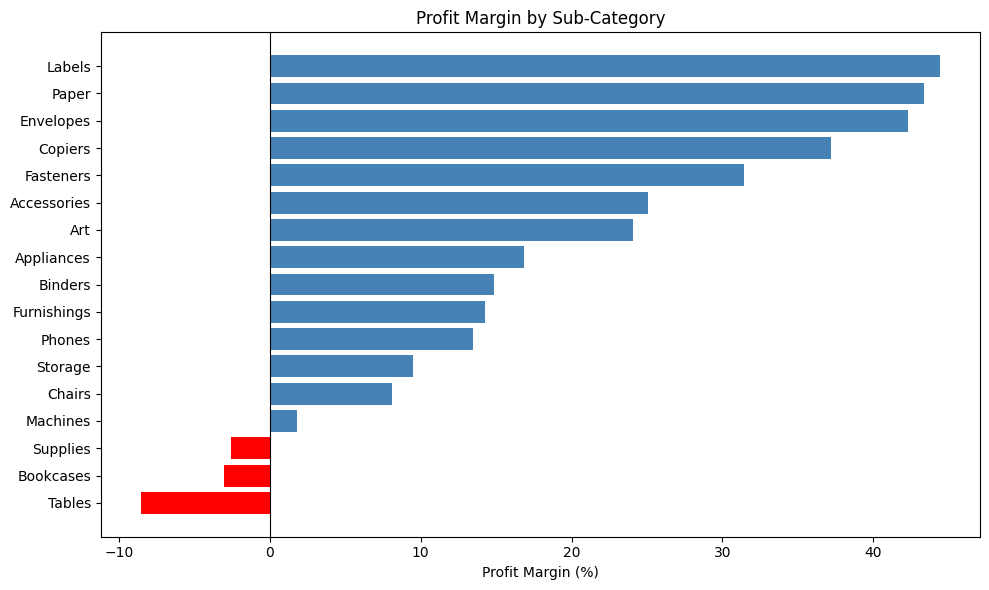

In [33]:
import matplotlib.pyplot as plt

colors = ['red' if x < 0 else 'steelblue' for x in margin_df['profit_margin_pct']]
plt.figure(figsize=(10, 6))
plt.barh(margin_df['sub_category'], margin_df['profit_margin_pct'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Profit Margin (%)')
plt.title('Profit Margin by Sub-Category')
plt.tight_layout()
plt.show()

Three sub-categories are actually negative once you break it down, not just weak. Tables is the worst at -8.56%, around £17,725 lost on £200k+ of sales, this is the biggest problem so far. Bookcases also negative at -3.02%.

Both are Furniture, explains the category number from before, it's not that the whole category is bad, it's really just these two dragging the average down while Chairs and Furnishings are fine.

Supplies also negative (-2.55%) but sits inside Office Supplies which looked fine overall, Paper and Labels are strong enough to hide it at category level.

## Sales and profit by region

Checking if any region stands out.

In [34]:
query = """
SELECT
    region,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin_pct,
    COUNT(*) AS num_orders
FROM orders_clean
GROUP BY region
ORDER BY profit_margin_pct ASC
"""

pd.read_sql(query, conn)

,region,total_sales,total_profit,profit_margin_pct,num_orders
0,Central,501239.89,39706.36,7.92,2323
1,South,391721.91,46749.43,11.93,1620
2,East,678781.24,91522.78,13.48,2848
3,West,725457.82,108418.45,14.94,3203


Central has the weakest margin at 7.92%, about half of West's 14.94%, even though Central and East have similar sales. Not actually losing money like Tables/Bookcases so it's not urgent, but the gap is big enough someone should probably look into it. If Central matched West's margin on the sales it already has that's close to double the profit for no extra sales.

## Top products within each category

Overall top 10 across the whole store isn't that useful since it'll just be dominated by Technology. Breaking it out by category instead.

In [35]:
query = """
WITH product_sales AS (
    SELECT
        category,
        product_name,
        ROUND(SUM(sales), 2) AS total_sales,
        ROUND(SUM(profit), 2) AS total_profit
    FROM orders_clean
    GROUP BY category, product_name
),
ranked_products AS (
    SELECT
        *,
        RANK() OVER (PARTITION BY category ORDER BY total_sales DESC) AS sales_rank
    FROM product_sales
)
SELECT category, product_name, total_sales, total_profit, sales_rank
FROM ranked_products
WHERE sales_rank <= 3
ORDER BY category, sales_rank
"""

pd.read_sql(query, conn)

,category,product_name,total_sales,total_profit,sales_rank
0,Furniture,HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00,1
1,Furniture,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.97,-669.54,2
2,Furniture,Bretford Rectangular Conference Table Tops,12995.29,-327.23,3
3,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04,1
4,Office Supplies,GBC DocuBind TL300 Electric Binding System,19823.48,2233.51,2
5,Office Supplies,GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98,3
6,Technology,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,1
7,Technology,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08,2
8,Technology,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,3


This one caught my eye. Furniture's top 3 best sellers by revenue is interesting because one breaks exactly even, the other two are losses (Bookcase -£669.54, Rectangular Conference Table Tops -£327.23). So the products the store sells the most of in Furniture are literally the ones losing money.

Technology looks fine because of the Canon copier (£25,199 profit) but its 2nd best seller, the Cisco TelePresence system, is also a loss at -£1,811. Same masking thing as Office Supplies before, a strong category average hiding a loss inside its own top sellers.

## Sales trend over time

Checking whether sales are actually growing over the 4 years and if there's a seasonal pattern.

In [36]:
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y', order_date) AS order_year,
        strftime('%m', order_date) AS order_month,
        strftime('%Y-%m', order_date) AS year_month,
        ROUND(SUM(sales), 2) AS total_sales
    FROM orders_clean
    GROUP BY order_year, order_month
)
SELECT
    order_year,
    order_month,
    year_month,
    total_sales,
    LAG(total_sales) OVER (ORDER BY order_year, order_month) AS prev_month_sales,
    ROUND(
        (total_sales - LAG(total_sales) OVER (ORDER BY order_year, order_month)) * 100.0
        / LAG(total_sales) OVER (ORDER BY order_year, order_month), 2
    ) AS growth_pct
FROM monthly_sales
ORDER BY order_year, order_month
"""

trend_df = pd.read_sql(query, conn)
trend_df

,order_year,order_month,year_month,total_sales,prev_month_sales,growth_pct
0,2014,01,2014-01,14236.90,NaN,NaN
1,2014,02,2014-02,4519.89,14236.90,-68.25
2,2014,03,2014-03,55691.01,4519.89,1132.13
3,2014,04,2014-04,28295.34,55691.01,-49.19
4,2014,05,2014-05,23648.29,28295.34,-16.42
5,2014,06,2014-06,34595.13,23648.29,46.29
6,2014,07,2014-07,33946.39,34595.13,-1.88
7,2014,08,2014-08,27909.47,33946.39,-17.78
8,2014,09,2014-09,81777.35,27909.47,193.01
9,2014,10,2014-10,31453.39,81777.35,-61.54


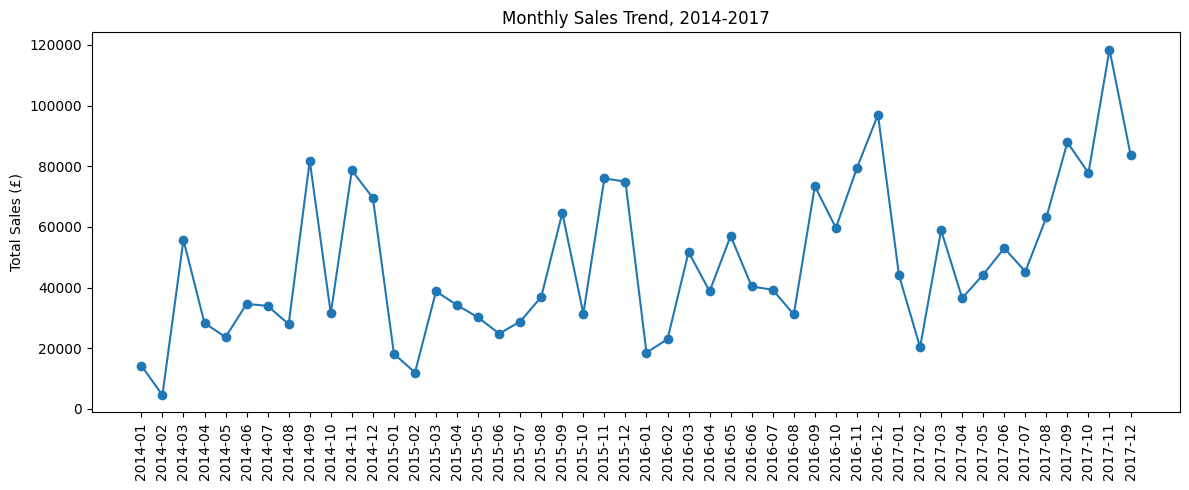

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(trend_df['year_month'], trend_df['total_sales'], marker='o')
plt.xticks(rotation=90)
plt.ylabel('Total Sales (£)')
plt.title('Monthly Sales Trend, 2014-2017')
plt.tight_layout()
plt.show()

Month to month growth alone is noisy, jumps and drops over 100% aren't unusual. But looking at the same months across years there's a clear pattern across this plot as Nov and Dec are always the strongest, Jan and Feb always the weakest right after. Consistent across all 4 years so it's seasonality, not just noise.

## Customer value segmentation

Splitting customers into tiers by total spend to see how much revenue comes from the top spenders vs everyone else.

In [38]:
query = """
WITH customer_spend AS (
    SELECT
        customer_id,
        customer_name,
        ROUND(SUM(sales), 2) AS total_spend,
        ROUND(SUM(profit), 2) AS total_profit,
        COUNT(DISTINCT order_id) AS num_orders
    FROM orders_clean
    GROUP BY customer_id, customer_name
),
customer_tiers AS (
    SELECT
        *,
        NTILE(4) OVER (ORDER BY total_spend DESC) AS spend_tier
    FROM customer_spend
)
SELECT
    spend_tier,
    COUNT(*) AS num_customers,
    ROUND(SUM(total_spend), 2) AS tier_total_spend,
    ROUND(SUM(total_spend) * 100.0 / (SELECT SUM(total_spend) FROM customer_spend), 2) AS pct_of_total_sales
FROM customer_tiers
GROUP BY spend_tier
ORDER BY spend_tier
"""
tier_df = pd.read_sql(query, conn)
tier_df

,spend_tier,num_customers,tier_total_spend,pct_of_total_sales
0,1,199,1266450.73,55.13
1,2,198,574885.82,25.03
2,3,198,330574.64,14.39
3,4,198,125289.75,5.45


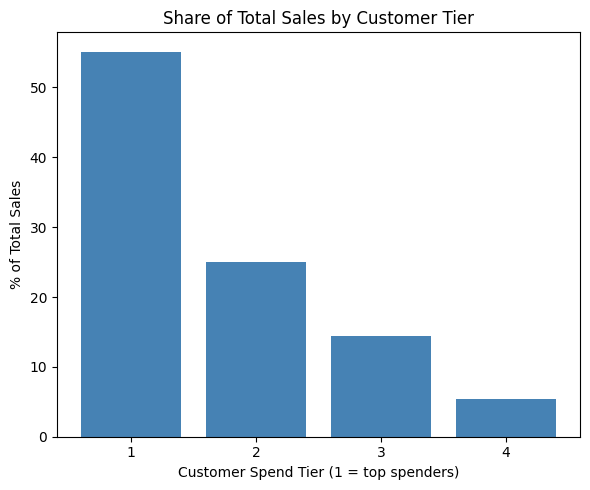

In [39]:
plt.figure(figsize=(6, 5))
plt.bar(tier_df['spend_tier'].astype(str), tier_df['pct_of_total_sales'], color='steelblue')
plt.xlabel('Customer Spend Tier (1 = top spenders)')
plt.ylabel('% of Total Sales')
plt.title('Share of Total Sales by Customer Tier')
plt.tight_layout()
plt.show()

Split into quartiles by spend, top 25% account for 55.13% of total sales, more than double what you'd expect if it was spread evenly. Drops off fast after that, tier 2 is roughly proportional at 25%, tiers 3 and 4 well below what you'd expect from their customer count, bottom 25% only make up 5.45%.

## Testing the discount idea

The analysis above pointed toward discount as a likely driver of the losses in Tables and Bookcases. I'm now testing whether higher discount = lower margin by grouping into discount bands.

In [40]:
query = """
SELECT
    CASE
        WHEN discount = 0 THEN '0%'
        WHEN discount <= 0.2 THEN '1-20%'
        WHEN discount <= 0.4 THEN '21-40%'
        WHEN discount <= 0.6 THEN '41-60%'
        ELSE '61%+'
    END AS discount_band,
    COUNT(*) AS num_orders,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin_pct
FROM orders_clean
GROUP BY discount_band
ORDER BY MIN(discount)
"""

band_df = pd.read_sql(query, conn)
band_df

,discount_band,num_orders,total_sales,total_profit,profit_margin_pct
0,0%,4798,1087908.47,320987.60,29.51
1,1-20%,3803,846522.24,100785.47,11.91
2,21-40%,460,234137.90,-35817.47,-15.30
3,41-60%,215,71048.21,-28944.19,-40.74
4,61%+,718,57584.04,-70614.40,-122.63


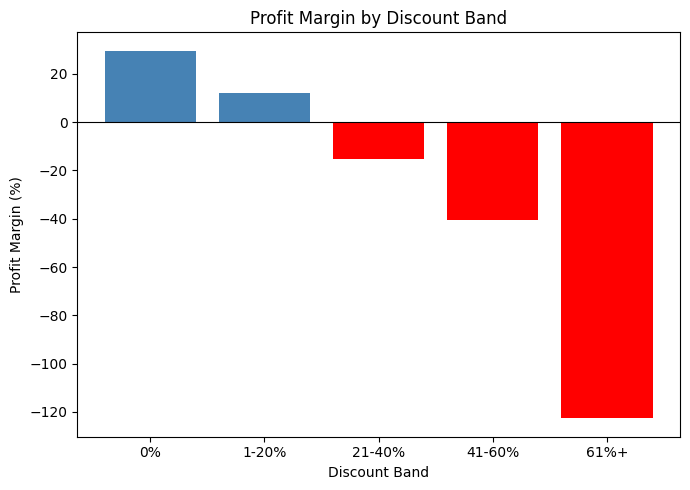

In [41]:
colors = ['red' if x < 0 else 'steelblue' for x in band_df['profit_margin_pct']]
plt.figure(figsize=(7, 5))
plt.bar(band_df['discount_band'], band_df['profit_margin_pct'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Discount Band')
plt.ylabel('Profit Margin (%)')
plt.title('Profit Margin by Discount Band')
plt.tight_layout()
plt.show()

Grouping into bands confirms it, margin drops as discount goes up. 29.51% at 0% discount, still positive but weaker at 1-20% (11.91%), turns negative at 21-40% (-15.30%) and keeps getting worse, down to -122.63% at 61%+.

That last number means the store loses more than the sale is even worth once discount goes past 60%. So above 20% starts to hurt and past 40% it's a real problem.

## Are Tables and Bookcases discounted more than everything else?

Checking average discount by sub-category to see if Tables/Bookcases are just being discounted harder than everyone else, which would explain why they're losing money.

In [42]:
query = """
SELECT
    sub_category,
    ROUND(AVG(discount) * 100, 2) AS avg_discount_pct,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin_pct
FROM orders_clean
GROUP BY sub_category
ORDER BY avg_discount_pct DESC
"""

pd.read_sql(query, conn)

,sub_category,avg_discount_pct,profit_margin_pct
0,Binders,37.23,14.86
1,Machines,30.61,1.79
2,Tables,26.13,-8.56
3,Bookcases,21.11,-3.02
4,Chairs,17.02,8.10
5,Appliances,16.65,16.87
6,Copiers,16.18,37.20
7,Phones,15.46,13.49
8,Furnishings,13.83,14.24
9,Fasteners,8.20,31.40


Tables (26.13% avg discount) and Bookcases (21.11%) are both near the top for discount and both negative margin so that fits. But Binders has the highest discount of anything (37.23%) and is still profitable at 14.86%. Machines is 2nd highest (30.61%) and only just stays positive (1.79%).

So discount matters a lot overall but it's not the whole story on its own, Tables and Bookcases seem to get hit worse by the same discount level than Binders does. Could be original markup/cost but there's no cost data here so can't actually prove that, just flagging it.

## Predicting whether an order will be profitable

Discount is clearly a big factor so wanted to try building something that predicts yes/no whether an order will be profitable, using the same features already looked at above.

### Setting up the target

1 if the order made a profit, 0 if it broke even or lost money.

In [43]:
df['is_profitable'] = (df['profit'] > 0).astype(int)

print(df['is_profitable'].value_counts())
print(df['is_profitable'].value_counts(normalize=True).round(3))

is_profitable
1    8058
0    1936
Name: count, dtype: int64
is_profitable
1    0.806
0    0.194
Name: proportion, dtype: float64


80.6% of orders are profitable, 19.4% aren't. Because of that imbalance accuracy on its own won't mean much, a model that just guessed profitable every time would already get 80.6% without learning anything. So precision/recall for the not-profitable class is what actually matters here. This is because precision will measure when the model says non-profitable how often is it right and recall looks at of all of the orders that were actually loss-making how many did the model catch.

### Features and train/test split

Using sales, discount, quantity, category, sub_category, region and segment, plus a sales x discount interaction term since discount's effect on profit probably depends on how big the order is. One-hot encoded the categorical stuff. Used stratify on the split so the 80/20 class balance stays the same in both train and test rather than leaving it to chance.

In [44]:
from sklearn.model_selection import train_test_split

model_df = df[['sales', 'discount', 'quantity', 'category', 'sub_category', 'region', 'segment', 'is_profitable']].copy()

model_df['sales_discount_interaction'] = model_df['sales'] * model_df['discount']

model_df = pd.get_dummies(model_df, columns=['category', 'sub_category', 'region', 'segment'], drop_first=True)

X = model_df.drop(columns=['is_profitable'])
y = model_df['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

print('training class balance:')
print(y_train.value_counts(normalize=True).round(3))
print('test class balance:')
print(y_test.value_counts(normalize=True).round(3))

training class balance:
is_profitable
1    0.806
0    0.194
Name: proportion, dtype: float64
test class balance:
is_profitable
1    0.806
0    0.194
Name: proportion, dtype: float64


### Fitting the model

I choose a Gradient Boosting Classifier, as it's a solid choice for this type of tabular data.

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('training rows:', X_train.shape[0])
print('test rows:', X_test.shape[0])

training rows: 7995
test rows: 1999


### Evaluating it

Accuracy isn't that useful here because of the imbalance, so looking at precision/recall/F1 for the not-profitable class specifically since that's the one that actually matters. Also printed the confusion matrix to see the actual breakdown.

In [46]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, target_names=['not profitable', 'profitable']))

print('confusion matrix:')
print(confusion_matrix(y_test, y_pred))

                precision    recall  f1-score   support

not profitable       0.91      0.77      0.84       387
    profitable       0.95      0.98      0.96      1612

      accuracy                           0.94      1999
     macro avg       0.93      0.88      0.90      1999
  weighted avg       0.94      0.94      0.94      1999

confusion matrix:
[[ 299   88]
 [  29 1583]]


94% weighted accuracy overall but the not-profitable numbers matter more. Precision 0.91, recall 0.77 so when it flags something as not profitable it's right 91% of the time, but it only catches 77% of the actual loss making orders, missing about 1 in 5. From the confusion matrix, 299 out of 387 genuinely unprofitable orders caught, 88 missed. Profitable class predicted really reliably (1583/1612 correct).

Decent result I think, more useful than trying to predict the exact profit number. Main weakness is still that 1 in 5 loss making orders get through, so it's a good first filter, not something to rely on completely by itself.

### Feature importance

Checking what the model actually relied on most.

In [47]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

discount                      0.815413
sales_discount_interaction    0.072508
sub_category_Storage          0.036429
sales                         0.017109
category_Office Supplies      0.012375
sub_category_Supplies         0.010560
sub_category_Copiers          0.007387
sub_category_Phones           0.005819
quantity                      0.005225
category_Technology           0.003282
dtype: float64

Discount alone is over 80% of what the model uses, plus another 8% from the sales/discount interaction so together almost 89%. Makes sense really, sales tells you how big the order could be but discount is what actually decides whether it tips into a loss.

### Using this before an order actually happens

None of the features need the order to have already gone through, category/sub_category/region/segment are known as soon as someone starts an order and discount/sales are known at the quoting stage. So this could actually be used before a sale happens rather than just explaining stuff after.

In theory someone setting up a quote could plug in the numbers, expected sale amount, discount, product, region, before confirming, and get a prediction on whether that combination is likely to be profitable based on everything seen historically. Won't catch everything since recall was only 79%, but it turns discounting from something checked after the fact into something checked before.

In [48]:
new_order = pd.DataFrame([{
    'sales': 1025,
    'discount': 0.30,
    'quantity': 3,
    'category': 'Furniture',
    'sub_category': 'Tables',
    'region': 'Central',
    'segment': 'Corporate'
}])

new_order['sales_discount_interaction'] = new_order['sales'] * new_order['discount']

new_order_encoded = pd.get_dummies(new_order, columns=['category', 'sub_category', 'region', 'segment'])
new_order_encoded = new_order_encoded.reindex(columns=X.columns, fill_value=0)

prediction = clf.predict(new_order_encoded)
probability = clf.predict_proba(new_order_encoded)

print('predicted profitable:', bool(prediction[0]))
print('probability of not profitable:', round(probability[0][0], 3))
print('probability of profitable:', round(probability[0][1], 3))

predicted profitable: False
probability of not profitable: 0.989
probability of profitable: 0.011


## Key findings and recommendations

### Furniture's best sellers are losing money

The products generating the most sales in Furniture aren't the ones making the most profit, a couple are actively losing money. The top ranked bookcase and table by sales both come out negative, top ranked chair only just breaks even. So the more Furniture the store sells at current pricing the more it risks losing rather than gaining, this lines up with Tables and Bookcases being the only two sub-categories in the whole dataset with negative overall margin (-8.56% and -3.02%).

Worth saying though, if these are being sold off deliberately to clear stock that changes things completely, I can't tell that from the data alone so it's something to actually ask whoever manages Furniture pricing before acting on it.

### Discount is the clearest driver of losses

Margin drops consistently as discount goes up, turning negative around 21% and getting a lot worse past 40%. Both the discount band comparison and the model back this up, discount alone made up over 80% of what the model relied on and it caught loss making orders with 91% precision and 77% recall.

Not the full picture though. Binders is discounted more than Tables (37% vs 26%) but stays profitable, so something's specific to Tables and Bookcases making them worse hit by the same discount level. Probably cost or markup but that's not in this dataset so can't say for sure.

### Central region underperforms on margin

Central isn't losing money but its margin (7.92%) is about half of West's (14.94%) on similar sales to East. If it matched West's margin on its current sales that's close to double the profit without any extra sales needed. Worth checking if it's heavier discounting specifically in Central or just more Tables/Bookcases being sold there.

### Recommendations

Review pricing and discount limits for Tables and Bookcases specifically since they're the only sub-categories losing money outright and check whether that's deliberate clearance or an actual pricing problem. Consider capping discount around 20% as a general policy since that's consistently where margin turns negative in this data. Look into why Central's margin lags behind other regions with similar sales.

The model from earlier doesn't have to be a one off thing either, since none of its inputs need the order to have already happened it could be run before an order is confirmed to flag likely loss making combinations upfront instead of only finding out after.

### Conclusion

Overall the store is doing fine on revenue but a chunk of it isn't turning into profit. Furniture, specifically Tables and Bookcases, is the clearest problem, the only two sub-categories actually losing money rather than just underperforming. Discount is the biggest single factor separating profitable orders from unprofitable ones and the model backs that up.

Central adds another angle, its margin lagging behind similar-sales regions is a real gap even without anything going negative. The recommendations above, the 20% discount cap, reviewing Tables/Bookcases pricing and looking into Central, all come straight from what's in the data. The model also doesn't stop being useful once this notebook is done, it can be run on proposed orders before they're confirmed which gives more of a live check instead of only finding out a pricing decision was wrong after the numbers come in.